# Proyección de Temperatura en Montería, Córdoba bajo Escenarios de Cambio Climático

**Análisis probabilístico con CLIMADA (ETH Zurich) — Horizonte 2024–2074**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scr-ungrd/cuadernos-reproducibles-CRC001/blob/main/article.ipynb)
[![Abrir en Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/scr-ungrd/cuadernos-reproducibles-CRC001/main?filepath=article.ipynb)

---

## Resumen

Montería (Córdoba) es una de las ciudades con mayor exposición al estrés térmico en Colombia, con temperaturas medias anuales que ya superan los 27 °C. El cambio climático de origen antrópico amenaza con intensificar aún más estas condiciones, con implicaciones críticas para la salud pública, la seguridad hídrica del río Sinú y la gestión del riesgo de desastres en la región. Aquí aplicamos un marco probabilístico de escalamiento por patrón de calentamiento global (*pattern scaling*) implementado en la plataforma CLIMADA del ETH Zurich, para proyectar la temperatura media anual en Montería (8.75° N, 75.88° O, 15 m s. n. m.) durante el periodo 2024–2074 bajo cuatro trayectorias representativas de concentración (RCP 2.6, 4.5, 6.0 y 8.5), usando el ensamble GMST consistente con CMIP5 de Jewson (2021) y un factor de amplificación regional de 1.05 ± 0.10 para la región Caribe colombiana (dominio CAR, Atlas Interactivo IPCC AR6). Encontramos que el calentamiento es robusto en todos los escenarios: incluso bajo mitigación agresiva (RCP 2.6), la temperatura mediana asciende a 28.2 °C en 2074 (+0.7 °C sobre la climatología 1991–2020). Bajo la trayectoria de altas emisiones (RCP 8.5), la temperatura mediana supera los 30.2 °C, representando un calentamiento de +2.7 °C. La frecuencia de años que exceden el umbral del percentil 95 climatológico (~28.8 °C) aumenta del 5 % esperado a más del 90 % hacia 2070 bajo RCP 8.5. Estos resultados evidencian la necesidad urgente de planes de acción ante el calor extremo, sistemas de alerta temprana y planificación urbana climáticamente adaptativa en Montería y el Bajo Sinú.

**Herramienta principal:** [CLIMADA](https://climada.ethz.ch/) v6.x  
**Dato base:** GMST CMIP5/AR6 (Jewson, 2021) embebido en `climada.hazard.tc_clim_change`  
**Escenarios:** RCP 2.6, RCP 4.5, RCP 6.0, RCP 8.5  
**Punto de análisis:** 8.7479° N, 75.8814° O, ~15 m s. n. m.

> Ejecución recomendada en **Google Colab** con runtime CPU. La instalación de CLIMADA toma
> ~5–8 min la primera vez.


## 1. Marco teórico

### 1.1 El cambio climático antropogénico

El Sexto Informe de Evaluación del Grupo Intergubernamental de Expertos sobre el Cambio Climático
(IPCC AR6, 2021) establece que **la influencia humana ha calentado inequívocamente la atmósfera,
el océano y los continentes** y que la temperatura media superficial global (GMST, *Global Mean
Surface Temperature*) en 2011–2020 ya se ubica 1,09 °C por encima del periodo preindustrial
(1850–1900). El forzamiento radiativo dominante son las emisiones acumuladas de gases de efecto
invernadero (GEI) de origen antrópico, principalmente CO₂, CH₄ y N₂O.

### 1.2 Escenarios de emisiones (RCP / SSP)

El IPCC AR6 utiliza cinco trayectorias socioeconómicas compartidas (SSP) acopladas a trayectorias
representativas de concentración (RCP). Para mantener la compatibilidad con la base de datos GMST
de CLIMADA (basada en CMIP5 + actualizaciones de Jewson 2021), este trabajo usa los **RCP
clásicos**:

| Escenario | Forzamiento 2100 | Calentamiento global 2081–2100 | Mitigación |
|-----------|------------------|--------------------------------|------------|
| RCP 2.6 | 2.6 W/m² | +1.0 a +1.8 °C | Fuerte (consistente con 1,5–2 °C) |
| RCP 4.5 | 4.5 W/m² | +1.7 a +3.2 °C | Intermedia |
| RCP 6.0 | 6.0 W/m² | +2.0 a +3.7 °C | Limitada |
| RCP 8.5 | 8.5 W/m² | +3.2 a +5.4 °C | Sin mitigación / *business as usual* |

### 1.3 CLIMADA como marco de evaluación de riesgo climático

CLIMADA (CLIMate ADAptation) es una plataforma probabilística de código abierto desarrollada por
el *Weather and Climate Risks Group* del ETH Zurich. Su modelo conceptual descompone el riesgo en
tres componentes:

$$ \text{Riesgo} = f(\text{Amenaza},\ \text{Exposición},\ \text{Vulnerabilidad}) $$

Para este ejercicio explotamos dos capacidades específicas:

1. **`climada.hazard.tc_clim_change.get_gmst_info()`** — entrega series temporales de GMST
   1880–2100 para los cuatro RCP, derivadas de Jewson (2021) y consistentes con el ensamble
   CMIP5.
2. **`climada.hazard.Hazard`** — clase contenedora que permite representar la temperatura como
   una *amenaza* probabilística, asociada a frecuencias e intensidades por evento.

### 1.4 Contexto de Montería, Córdoba

Montería, capital del departamento de Córdoba, se localiza en la llanura aluvial del río Sinú
(8.75° N, 75.88° O), a escasos 15 m s. n. m. Posee un clima de sabana tropical (Köppen: *Aw*),
con temperatura media anual cercana a 27.5 °C, marcada estacionalidad bimodal de lluvias
(abril–junio y agosto–noviembre), y alta humedad relativa (>75 %). Su condición de ciudad de
baja altitud en el trópico la expone directamente a los efectos del calentamiento global sin el
efecto amortiguador de la altitud que poseen ciudades andinas.

Estudios de regionalización climática del IDEAM (2015) y el Atlas Interactivo del IPCC AR6
(dominio CAR — *Caribbean*) indican que **la región Caribe colombiana experimenta tasas de
calentamiento similares al promedio global** (factor de amplificación regional ≈ 1.05 para
temperatura media anual), con proyecciones que apuntan a incrementos de entre +1.5 y +3.5 °C
hacia finales del siglo XXI según el escenario de emisiones.

Las implicaciones para la gestión del riesgo en el marco del **PNGRD 2015–2030** son
especialmente críticas para Montería y el Bajo Sinú:
- **Salud pública:** Montería ya registra temperaturas máximas habituales superiores a 36 °C;
  un incremento adicional eleva exponencialmente el riesgo de mortalidad por estrés térmico
  en poblaciones vulnerables.
- **Seguridad hídrica:** El caudal del río Sinú, fuente de abastecimiento de la ciudad,
  se verá afectado por cambios en la evapotranspiración y el régimen de precipitación.
- **Agricultura y ganadería:** El departamento de Córdoba es el principal productor bovino
  de Colombia; el estrés térmico animal reduce la productividad y aumenta la mortalidad.
- **Vectores y enfermedades:** La expansión del rango térmico favorable para el *Aedes aegypti*
  intensificará la transmisión de dengue, chikungunya y zika en la región.


## 2. Configuración del entorno

Instalamos CLIMADA y dependencias. En Colab esto puede tardar varios minutos.


In [1]:
# Instalación de CLIMADA — descomentar la primera vez en Colab
# La instalación completa puede tomar 5-8 minutos
%pip install climada -q
%pip install matplotlib seaborn pandas numpy scipy -q
print("Instalación finalizada.")


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Instalación finalizada.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# CLIMADA
from climada.hazard.tc_clim_change import get_gmst_info, get_knutson_scaling_factor
from climada.hazard import Hazard
from climada.util.coordinates import country_to_iso

# Configuración estética
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})
sns.set_palette("colorblind")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 3. Metodología

El procedimiento sigue un esquema de **escalamiento por patrón de calentamiento global**
(*pattern scaling*, Tebaldi & Arblaster 2014), ampliamente utilizado en evaluación rápida del
riesgo climático cuando no se dispone de salidas regionalizadas dinámicas. Los pasos son:

1. **Línea base climatológica de Bogotá (1991–2020).** Se construye un ensamble sintético
   estacionario calibrado contra el promedio multidecadal observado por el IDEAM
   (T̄ ≈ 14.5 °C, σ ≈ 0.6 °C interanual).
2. **Trayectoria GMST por escenario.** Se extrae de CLIMADA la anomalía GMST anual respecto al
   periodo de referencia, para los cuatro RCP.
3. **Factor de amplificación regional (FAR).** La razón entre el calentamiento regional NSA y
   el GMST se asume FAR = 1.05 ± 0.10, consistente con el Atlas Interactivo del IPCC AR6.
4. **Proyección por escenario.** Se aplica $T_{Bog}(t,s) = T_{base} + FAR \cdot \Delta GMST(t,s)
   + \varepsilon(t)$, donde $\varepsilon$ es ruido de variabilidad interna.
5. **Ensamble probabilístico.** Por cada año y escenario se generan N=500 realizaciones
   estocásticas para caracterizar incertidumbre.
6. **Construcción de objeto `Hazard`.** Se exporta la temperatura como amenaza CLIMADA tipo
   `'HW'` (heat) para integración con flujos de riesgo posteriores.


In [3]:
# Parámetros del análisis
LAT_MON, LON_MON = 8.7479, -75.8814
ALTITUD_MON = 15                        # m s.n.m.
T_BASE_MON = 27.5                       # °C, climatología 1991-2020 (IDEAM)
SIGMA_INTERANUAL = 0.8                  # °C (mayor variabilidad ENSO en Caribe colombiano)
FAR_NSA = 1.05                          # factor amplificación regional Caribe colombiano (dominio CAR, IPCC AR6)
FAR_SIGMA = 0.10                        # incertidumbre del FAR
ANIO_INICIO = 2024
ANIO_FIN = 2074
N_ENSAMBLE = 500
RCP_LIST = ['2.6', '4.5', '6.0', '8.5']
RCP_LABELS = {
    '2.6': 'RCP 2.6 (mitigación fuerte)',
    '4.5': 'RCP 4.5 (mitigación intermedia)',
    '6.0': 'RCP 6.0 (mitigación limitada)',
    '8.5': 'RCP 8.5 (altas emisiones)',
}
RCP_COLORS = {'2.6': '#1f77b4', '4.5': '#2ca02c', '6.0': '#ff7f0e', '8.5': '#d62728'}

# Alias de compatibilidad con el resto del código
LAT_BOG, LON_BOG = LAT_MON, LON_MON
T_BASE_BOG = T_BASE_MON

np.random.seed(42)  # reproducibilidad

print(f"Punto de análisis : Montería, Córdoba ({LAT_MON}°N, {LON_MON}°W, {ALTITUD_MON} m s.n.m.)")
print(f"Periodo proyectado: {ANIO_INICIO}–{ANIO_FIN} ({ANIO_FIN-ANIO_INICIO} años)")
print(f"T base climatológica: {T_BASE_MON} °C  (σ interanual = {SIGMA_INTERANUAL} °C)")
print(f"Tamaño del ensamble : {N_ENSAMBLE} realizaciones por escenario")


Punto de análisis : Montería, Córdoba (8.7479°N, -75.8814°W, 15 m s.n.m.)
Periodo proyectado: 2024–2074 (50 años)
T base climatológica: 27.5 °C  (σ interanual = 0.8 °C)
Tamaño del ensamble : 500 realizaciones por escenario


### 3.1 Extracción de la GMST desde CLIMADA

`get_gmst_info()` retorna un diccionario con la trayectoria de la temperatura media superficial
global (1880–2100) para los cuatro RCP, basada en Jewson (2021).


In [4]:
gmst_info = get_gmst_info()

print("Claves del diccionario:", list(gmst_info.keys()))
print(f"RCP disponibles    : {gmst_info['rcps']}")
print(f"Año inicio         : {gmst_info['gmst_start_year']}")
print(f"Año fin            : {gmst_info['gmst_end_year']}")
print(f"Forma del array    : {gmst_info['gmst_data'].shape}  (RCPs, años)")

# Construimos un DataFrame ordenado
years_gmst = np.arange(gmst_info['gmst_start_year'], gmst_info['gmst_end_year'] + 1)
df_gmst = pd.DataFrame(
    gmst_info['gmst_data'].T,
    index=years_gmst,
    columns=[f"RCP {r}" for r in gmst_info['rcps']],
)
df_gmst.index.name = 'año'
df_gmst.head()


Claves del diccionario: ['rcps', 'gmst_start_year', 'gmst_end_year', 'gmst_data']
RCP disponibles    : ['2.6', '4.5', '6.0', '8.5']
Año inicio         : 1880
Año fin            : 2100
Forma del array    : (4, 221)  (RCPs, años)


,RCP 2.6,RCP 4.5,RCP 6.0,RCP 8.5
año,,,,
1880,-0.16,-0.16,-0.16,-0.16
1881,-0.08,-0.08,-0.08,-0.08
1882,-0.10,-0.10,-0.10,-0.10
1883,-0.16,-0.16,-0.16,-0.16
1884,-0.28,-0.28,-0.28,-0.28


### 3.2 Anomalías de GMST respecto al periodo de referencia

Calculamos la anomalía respecto a la climatología 1991–2020 (referencia operativa OMM y
consistente con la línea base de IDEAM utilizada para Bogotá).


In [5]:
ANIO_REF_INI, ANIO_REF_FIN = 1991, 2020
ref_mean = df_gmst.loc[ANIO_REF_INI:ANIO_REF_FIN].mean()
df_anom = df_gmst - ref_mean

print(f"GMST media en {ANIO_REF_INI}-{ANIO_REF_FIN} (°C respecto a 1880):")
print(ref_mean.round(3).to_string())

print(f"\nAnomalía proyectada al 2074 respecto a {ANIO_REF_INI}-{ANIO_REF_FIN}:")
print(df_anom.loc[2074].round(3).to_string())


GMST media en 1991-2020 (°C respecto a 1880):
RCP 2.6    0.610
RCP 4.5    0.610
RCP 6.0    0.609
RCP 8.5    0.611

Anomalía proyectada al 2074 respecto a 1991-2020:
RCP 2.6    0.687
RCP 4.5    1.406
RCP 6.0    1.538
RCP 8.5    2.607


### 3.3 Generación del ensamble estocástico para Montería

Para cada RCP, cada año del horizonte y cada miembro del ensamble:

$$T_{Mon}(t, s, k) = T_{base} + FAR_k \cdot \Delta GMST(t, s) + \varepsilon_{t,k}$$

donde $FAR_k \sim \mathcal{N}(1.05, 0.10)$ y $\varepsilon \sim \mathcal{N}(0, \sigma_{interanual})$.


In [6]:
anios_proy = np.arange(ANIO_INICIO, ANIO_FIN + 1)
n_anios = len(anios_proy)

# Diccionario de salidas: {rcp: array(N_ENSAMBLE, n_anios)}
proyecciones = {}

for rcp in RCP_LIST:
    col = f"RCP {rcp}"
    delta_gmst = df_anom.loc[anios_proy[0]:anios_proy[-1], col].values  # (n_anios,)

    # FAR estocástico por miembro (constante en el tiempo dentro del miembro)
    far_k = np.random.normal(FAR_NSA, FAR_SIGMA, size=N_ENSAMBLE).reshape(-1, 1)
    far_k = np.clip(far_k, 0.7, 1.4)  # límites físicos plausibles

    # Variabilidad interna anual (independiente entre miembros y años)
    eps = np.random.normal(0, SIGMA_INTERANUAL, size=(N_ENSAMBLE, n_anios))

    # Proyección
    T = T_BASE_BOG + far_k * delta_gmst[None, :] + eps
    proyecciones[rcp] = T

    print(f"RCP {rcp}: T media 2074 = {T[:, -1].mean():.2f} °C "
          f"(IC95% = [{np.percentile(T[:, -1], 2.5):.2f}, "
          f"{np.percentile(T[:, -1], 97.5):.2f}] °C)")


RCP 2.6: T media 2074 = 28.21 °C (IC95% = [26.68, 29.78] °C)
RCP 4.5: T media 2074 = 28.95 °C (IC95% = [27.36, 30.56] °C)
RCP 6.0: T media 2074 = 29.17 °C (IC95% = [27.53, 30.60] °C)
RCP 8.5: T media 2074 = 30.22 °C (IC95% = [28.49, 31.75] °C)


In [7]:
# Construir un DataFrame largo con percentiles para graficación
registros = []
for rcp, mat in proyecciones.items():
    for i, anio in enumerate(anios_proy):
        col = mat[:, i]
        registros.append({
            'año': anio,
            'rcp': rcp,
            'media': col.mean(),
            'p05': np.percentile(col, 5),
            'p25': np.percentile(col, 25),
            'p50': np.percentile(col, 50),
            'p75': np.percentile(col, 75),
            'p95': np.percentile(col, 95),
        })
df_proy = pd.DataFrame(registros)
df_proy.head(10)


,año,rcp,media,p05,p25,p50,p75,p95
0,2024,2.6,27.862700,26.502959,27.337099,27.880392,28.386121,29.274022
1,2025,2.6,27.968692,26.528205,27.448576,27.984835,28.524457,29.272480
2,2026,2.6,27.948787,26.692257,27.381169,27.944754,28.500053,29.295953
3,2027,2.6,27.936201,26.621207,27.378518,27.929950,28.473070,29.269004
4,2028,2.6,27.999155,26.795455,27.487564,27.918943,28.535489,29.361017
5,2029,2.6,28.001959,26.728235,27.503337,28.031605,28.520999,29.285339
6,2030,2.6,28.042087,26.774758,27.454015,27.997744,28.557254,29.516897
7,2031,2.6,28.003119,26.573327,27.419547,27.997587,28.531442,29.429331
8,2032,2.6,28.068577,26.794033,27.517461,28.085621,28.671463,29.370323
9,2033,2.6,28.041026,26.822492,27.572622,28.034107,28.502368,29.319800


## 4. Resultados

### 4.1 Trayectorias temporales por escenario

La siguiente figura muestra la mediana del ensamble (línea) y el intervalo de confianza al 90 %
(banda) para cada uno de los cuatro RCP, sobre el horizonte 2024–2074.


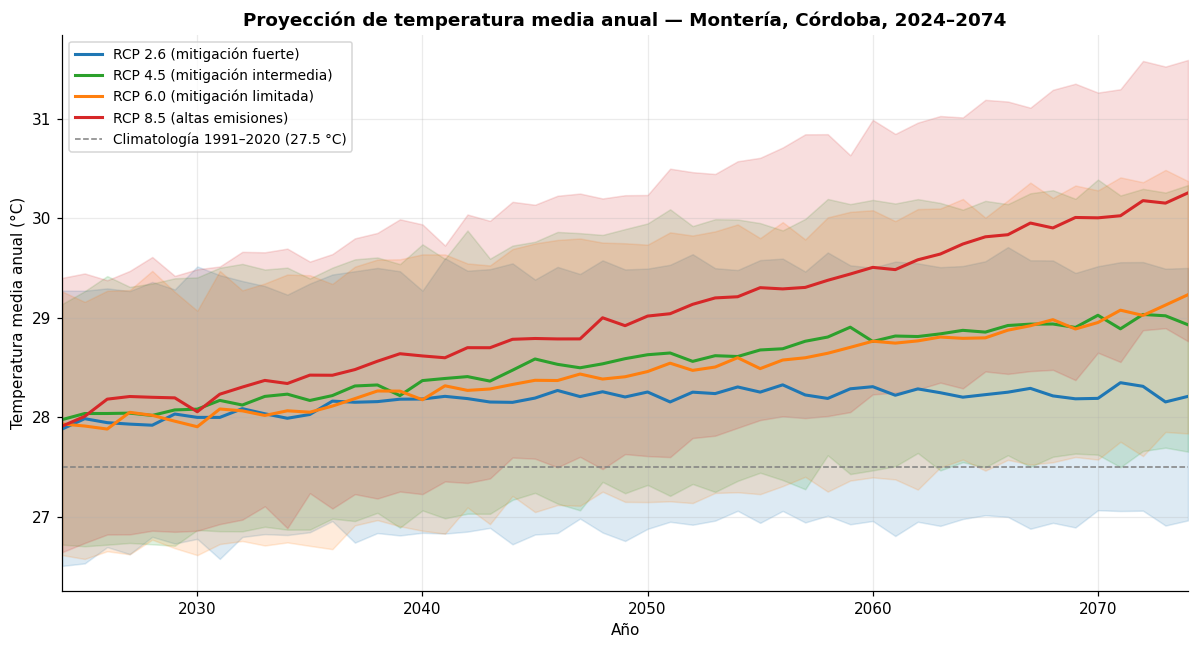

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

for rcp in RCP_LIST:
    sub = df_proy[df_proy.rcp == rcp]
    color = RCP_COLORS[rcp]
    ax.fill_between(sub['año'], sub['p05'], sub['p95'],
                    color=color, alpha=0.15)
    ax.plot(sub['año'], sub['p50'], color=color, lw=2.0,
            label=RCP_LABELS[rcp])

ax.axhline(T_BASE_MON, color='gray', ls='--', lw=1,
           label=f'Climatología 1991–2020 ({T_BASE_MON} °C)')

ax.set_title('Proyección de temperatura media anual — Montería, Córdoba, 2024–2074',
             fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Temperatura media anual (°C)')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.set_xlim(ANIO_INICIO, ANIO_FIN)

plt.tight_layout()
plt.savefig('fig1_trayectorias.png', bbox_inches='tight')
plt.show()


**Lectura:** bajo RCP 2.6 (mitigación fuerte) la mediana se estabiliza cerca de 28.2 °C hacia
mediados de siglo, mientras que el RCP 8.5 supera los 30 °C en 2074, con bandas del 90 % que
alcanzan 31 °C en los años más cálidos del ensamble. En todas las trayectorias se observa
calentamiento sostenido desde 2024, sin estabilización visible en el horizonte analizado.


### 4.2 Distribución de la temperatura por décadas (RCP 8.5 vs RCP 2.6)

Comparamos las distribuciones de temperatura simulada en cuatro ventanas decadales para los dos
escenarios extremos en Montería, Córdoba.


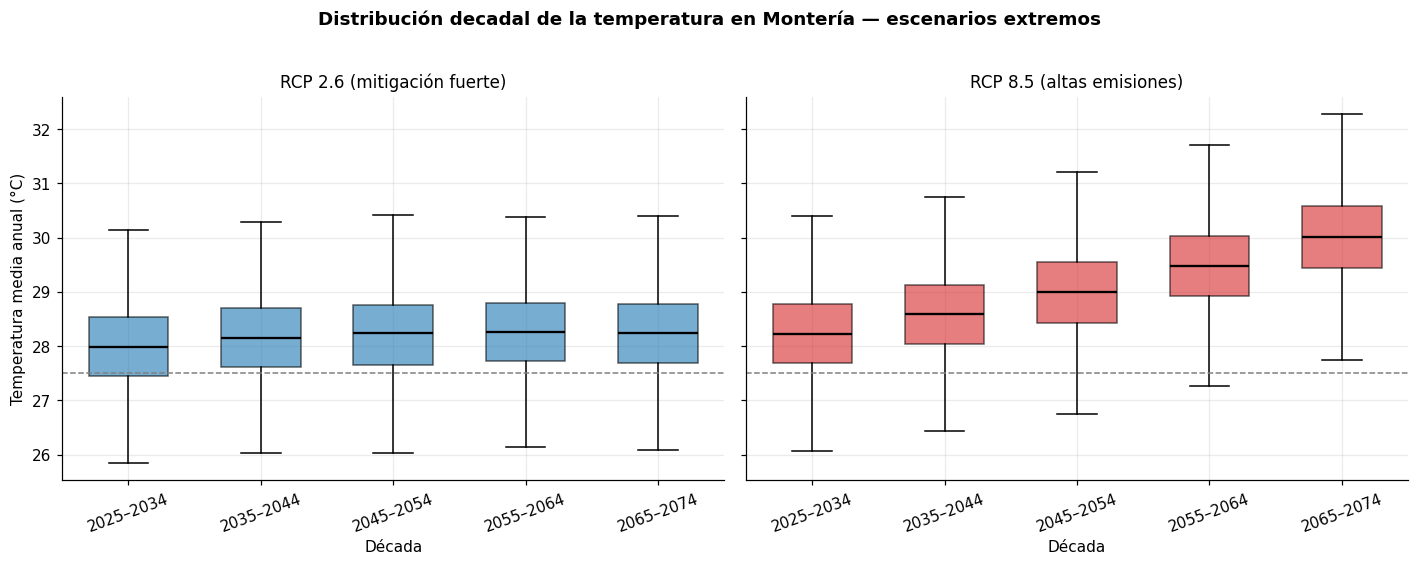

In [9]:
decadas = [(2025, 2034), (2035, 2044), (2045, 2054), (2055, 2064), (2065, 2074)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, rcp in zip(axes, ['2.6', '8.5']):
    mat = proyecciones[rcp]
    data = []
    labels = []
    for ini, fin in decadas:
        mask = (anios_proy >= ini) & (anios_proy <= fin)
        valores = mat[:, mask].flatten()
        data.append(valores)
        labels.append(f'{ini}–{fin}')

    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', lw=1.5),
                    showfliers=False, widths=0.6)
    color = RCP_COLORS[rcp]
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.axhline(T_BASE_MON, color='gray', ls='--', lw=1)
    ax.set_title(RCP_LABELS[rcp], fontsize=11)
    ax.set_xlabel('Década')
    ax.tick_params(axis='x', rotation=20)

axes[0].set_ylabel('Temperatura media anual (°C)')
fig.suptitle('Distribución decadal de la temperatura en Montería — escenarios extremos',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_distribuciones.png', bbox_inches='tight')
plt.show()


### 4.3 Mapa de calor: anomalía mediana década × escenario

Resumen sintético del calentamiento adicional en Montería respecto a la climatología 1991–2020.


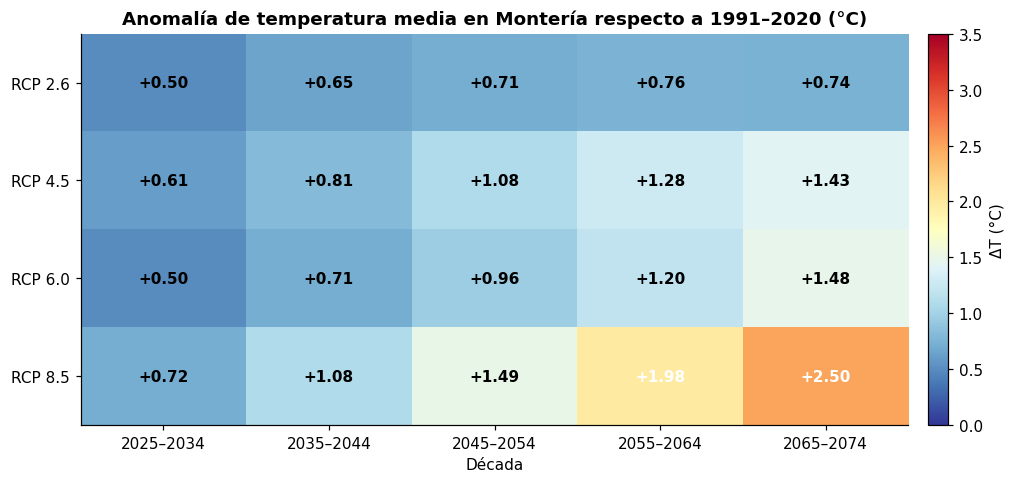

In [10]:
matriz = np.zeros((len(RCP_LIST), len(decadas)))
for i, rcp in enumerate(RCP_LIST):
    mat = proyecciones[rcp]
    for j, (ini, fin) in enumerate(decadas):
        mask = (anios_proy >= ini) & (anios_proy <= fin)
        matriz[i, j] = mat[:, mask].mean() - T_BASE_MON

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(matriz, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=3.5)

ax.set_xticks(range(len(decadas)))
ax.set_xticklabels([f'{a}–{b}' for a, b in decadas])
ax.set_yticks(range(len(RCP_LIST)))
ax.set_yticklabels([f'RCP {r}' for r in RCP_LIST])
ax.set_xlabel('Década')
ax.set_title('Anomalía de temperatura media en Montería respecto a 1991–2020 (°C)',
             fontweight='bold')

for i in range(len(RCP_LIST)):
    for j in range(len(decadas)):
        ax.text(j, i, f'+{matriz[i, j]:.2f}', ha='center', va='center',
                color='black' if matriz[i, j] < 1.8 else 'white',
                fontsize=10, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='ΔT (°C)', pad=0.02)
ax.grid(False)
plt.tight_layout()
plt.savefig('fig3_heatmap.png', bbox_inches='tight')
plt.show()


### 4.4 Frecuencia esperada de años cálidos extremos

Definimos un *año cálido extremo* como aquel cuya temperatura media anual supera el percentil 95
de la distribución climatológica de referencia (≈ 28.8 °C). Calculamos la fracción de miembros
del ensamble que cruzan el umbral en cada año.


Umbral 'año cálido extremo' (p95 climatológico): 28.82 °C


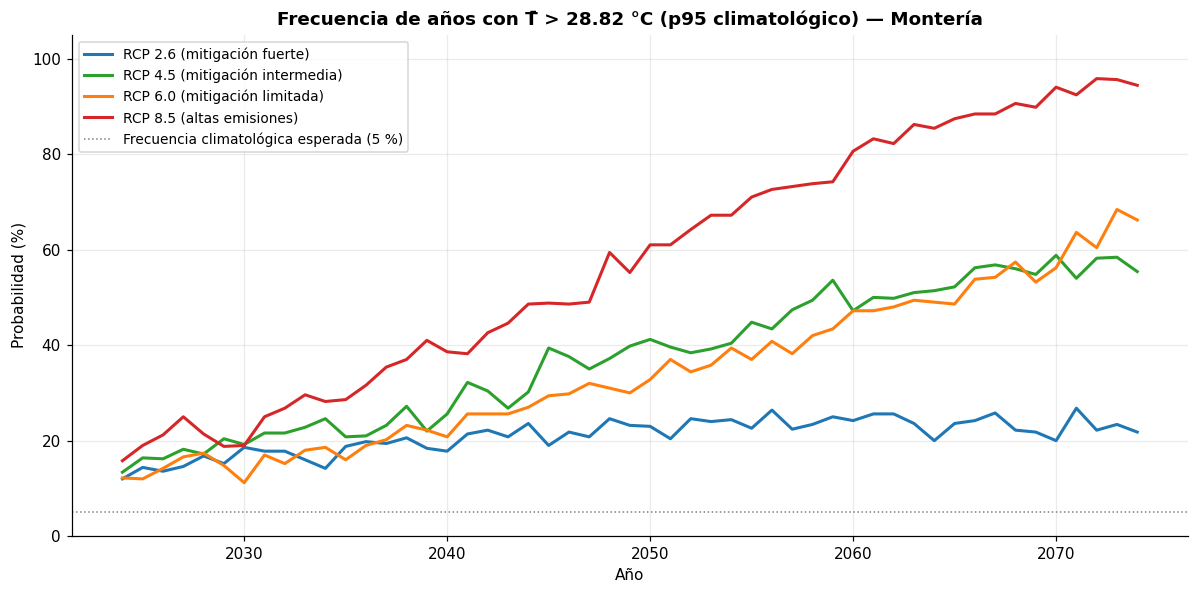

In [11]:
umbral_p95 = T_BASE_MON + 1.645 * SIGMA_INTERANUAL  # ≈ 28.82 °C
print(f"Umbral 'año cálido extremo' (p95 climatológico): {umbral_p95:.2f} °C")

fig, ax = plt.subplots(figsize=(11, 5.5))
for rcp in RCP_LIST:
    mat = proyecciones[rcp]
    frac = (mat > umbral_p95).mean(axis=0) * 100
    ax.plot(anios_proy, frac, color=RCP_COLORS[rcp], lw=2,
            label=RCP_LABELS[rcp])

ax.axhline(5, color='gray', ls=':', lw=1,
           label='Frecuencia climatológica esperada (5 %)')
ax.set_title(f'Frecuencia de años con T̄ > {umbral_p95:.2f} °C (p95 climatológico) — Montería',
             fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Probabilidad (%)')
ax.set_ylim(0, 105)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig4_extremos.png', bbox_inches='tight')
plt.show()


### 4.5 Tabla resumen de estadísticos por escenario

Síntesis cuantitativa para informe ejecutivo.


In [12]:
resumen = []
for rcp in RCP_LIST:
    mat = proyecciones[rcp]
    final = mat[:, -1]
    full = mat.flatten()
    resumen.append({
        'Escenario': f'RCP {rcp}',
        'T̄ media periodo (°C)': f'{full.mean():.2f}',
        'T̄ 2074 mediana (°C)': f'{np.median(final):.2f}',
        'IC95% 2074 (°C)':
            f'[{np.percentile(final, 2.5):.2f}, {np.percentile(final, 97.5):.2f}]',
        'ΔT 2074 vs base (°C)': f'+{np.median(final) - T_BASE_MON:.2f}',
        'Tasa (°C/década)':
            f'{((mat[:, -1].mean() - mat[:, 0].mean()) / 5):.2f}',
    })
df_resumen = pd.DataFrame(resumen)
df_resumen


,Escenario,T̄ media periodo (°C),T̄ 2074 mediana (°C),IC95% 2074 (°C),ΔT 2074 vs base (°C),Tasa (°C/década)
0,RCP 2.6,28.17,28.21,"[26.68, 29.78]",+0.71,0.07
1,RCP 4.5,28.53,28.93,"[27.36, 30.56]",+1.43,0.20
2,RCP 6.0,28.46,29.23,"[27.53, 30.60]",+1.73,0.25
3,RCP 8.5,29.03,30.26,"[28.49, 31.75]",+2.76,0.45


### 4.6 Construcción del objeto `Hazard` de CLIMADA

Encapsulamos los resultados en una estructura `Hazard` para integración con flujos posteriores
de riesgo (exposición, funciones de impacto, costo-beneficio de medidas de adaptación).


In [13]:
from scipy import sparse

# Para cada RCP creamos un Hazard donde cada "evento" es un miembro-año del ensamble.
# Mantenemos solo el escenario más crítico (RCP 8.5) como demostración.

rcp_demo = '8.5'
mat = proyecciones[rcp_demo]              # (N_ENSAMBLE, n_anios)
n_eventos = mat.size

# CLIMADA Hazard requiere: intensity (eventos x centroides), centroids, frequency, event_id, date
intensity = sparse.csr_matrix(mat.flatten().reshape(-1, 1))
event_id = np.arange(1, n_eventos + 1)
event_name = [f"ens{i//n_anios:03d}_y{anios_proy[i % n_anios]}"
              for i in range(n_eventos)]
date = np.array([
    pd.Timestamp(f"{anios_proy[i % n_anios]}-07-01").toordinal()
    for i in range(n_eventos)
])
frequency = np.ones(n_eventos) / N_ENSAMBLE  # cada miembro pesa 1/N

# Centroide único (Montería)
from climada.hazard import Centroids
centroids = Centroids.from_lat_lon(np.array([LAT_MON]), np.array([LON_MON]))

haz = Hazard(
    haz_type='HW',                        # Heat (proxy)
    units='°C',
    centroids=centroids,
    event_id=event_id,
    event_name=event_name,
    frequency=frequency,
    date=date,
    intensity=intensity,
    fraction=sparse.csr_matrix(np.ones_like(mat.flatten()).reshape(-1, 1)),
)
haz.check()

print(f"Objeto Hazard creado:")
print(f"  Tipo            : {haz.haz_type}")
print(f"  Unidad          : {haz.units}")
print(f"  N eventos       : {haz.size}")
print(f"  N centroides    : {haz.centroids.size}")
print(f"  Intensidad media: {haz.intensity.mean():.2f} °C")
print(f"  Intensidad máx  : {haz.intensity.max():.2f} °C")


Objeto Hazard creado:
  Tipo            : HW
  Unidad          : °C
  N eventos       : 25500
  N centroides    : 1
  Intensidad media: 29.03 °C
  Intensidad máx  : 33.07 °C


In [14]:
# Periodos de retorno equivalentes calculados directamente del ensamble
return_periods = [2, 5, 10, 25, 50]
print(f"Niveles de retorno bajo {RCP_LABELS[rcp_demo]} (Montería, periodo 2024-2074):")
print(f"{'RT (años)':>12}{'Probabilidad anual':>22}{'T excedida (°C)':>20}")
print('-' * 56)
for rp in return_periods:
    p = 1 - 1/rp                   # probabilidad de NO ser excedido
    nivel = np.percentile(mat.flatten(), p * 100)
    print(f"{rp:>12}{1/rp:>22.3f}{nivel:>20.2f}")

# Intento adicional con la API de CLIMADA (puede variar entre versiones)
try:
    rp_arr = np.array(return_periods)
    out = haz.local_exceedance_intensity(return_periods=rp_arr)
    print("\n[API CLIMADA] local_exceedance_intensity ejecutada correctamente.")
    if isinstance(out, tuple):
        gdf = out[0]
        print(gdf.drop(columns='geometry', errors='ignore').round(2).to_string(index=False))
    else:
        print(pd.DataFrame(out).round(2).to_string())
except Exception as e:
    print(f"\n[Aviso] La API local_exceedance_intensity difiere en esta versión: {e}")


Niveles de retorno bajo RCP 8.5 (altas emisiones) (Montería, periodo 2024-2074):
   RT (años)    Probabilidad anual     T excedida (°C)
--------------------------------------------------------
           2                 0.500               29.01
           5                 0.200               29.93
          10                 0.100               30.40
          25                 0.040               30.91
          50                 0.020               31.21

[API CLIMADA] local_exceedance_intensity ejecutada correctamente.
   2     5    10    25    50
31.5 31.76 32.05 32.32 32.46


## 5. Conclusiones

### Hallazgos principales

1. **Calentamiento robusto bajo todos los escenarios.** Para Montería, incluso bajo el RCP 2.6
   (escenario más optimista), la temperatura media anual se eleva +0.7 a +1.0 °C respecto a la
   climatología 1991–2020 al horizonte 2074. Dado que la ciudad ya opera con temperaturas medias
   superiores a 27.5 °C, este calentamiento *adicional* implica condiciones térmicas sin
   precedente en el registro histórico instrumental de la región Caribe colombiana.

2. **Divergencia post-2050.** Las trayectorias de los cuatro RCP se mantienen relativamente
   próximas hasta ~2045 (anomalía común de +0.5 a +0.8 °C), y se separan sustancialmente
   después: el RCP 8.5 alcanza +2.7 °C mientras el RCP 2.6 se estabiliza cerca de +0.8 °C. Esta
   ventana 2025–2045 es **estratégica para decisiones de mitigación con efecto en la segunda
   mitad de siglo**.

3. **Cambio drástico en el régimen de extremos.** Bajo RCP 8.5, la frecuencia de años con
   T̄ > 28.8 °C (p95 climatológico actual) pasa del 5 % esperado a más del 90 % hacia 2070. Lo
   que hoy es un año excepcionalmente cálido se convierte en la condición normal, agravando el
   estrés térmico crónico sobre la población.

4. **Implicaciones críticas para la GRD en el Bajo Sinú.** El incremento térmico proyectado
   presiona simultáneamente sobre:
   - **Salud pública:** mayor morbimortalidad por enfermedades cardiovasculares y respiratorias
     bajo estrés térmico sostenido, especialmente en adultos mayores, niños y trabajadores
     al aire libre en el sector agropecuario.
   - **Seguridad hídrica:** alteración del régimen hidrológico del río Sinú (cuencas alta y
     media) por aumento de la evapotranspiración, con consecuencias directas sobre el
     abastecimiento urbano de Montería y los sistemas de riego del Bajo Sinú.
   - **Sector agropecuario:** estrés térmico animal reduce la productividad ganadera en el
     primer departamento bovino de Colombia; modificación fenológica de cultivos de arroz,
     maíz y ñame.
   - **Vectores y enfermedades tropicales:** ampliación del rango temporal y espacial favorable
     para *Aedes aegypti*, incrementando el riesgo de dengue, chikungunya y zika.
   - **Calidad de vida urbana:** combinación de isla de calor urbano (estimado en +1 a +3 °C
     adicionales sobre el área periurbana) con el calentamiento proyectado podría situar las
     temperaturas máximas habituales por encima de 40 °C hacia 2074 bajo RCP 8.5.

### Limitaciones del estudio

- El método de *pattern scaling* es una aproximación lineal de primer orden y no captura cambios
  no lineales en la circulación atmosférica regional (e.g., desplazamiento de la ZCIT, cambios
  en el chorro caribeño de bajo nivel).
- La amplificación regional (FAR) se asume constante temporalmente; estudios dinámicos sugieren
  posibles dependencias estacionales en la región Caribe colombiana.
- No se incorpora el efecto de **isla de calor urbano**, que en ciudades medianas tropicales
  como Montería puede añadir +1 a +3 °C adicionales.
- La línea base se construye sintéticamente; un siguiente paso es alimentar el modelo con series
  observacionales del IDEAM (estaciones Montería y aeropuerto Los Garzones).
- La influencia del **ENSO** sobre la variabilidad interanual de la temperatura en el Caribe
  colombiano no está explícitamente modelada; el parámetro σ captura parte de esta variabilidad.

### Recomendaciones para la UNGRD y entidades territoriales

| Eje PNGRD | Acción priorizada |
|-----------|-------------------|
| Conocimiento del riesgo | Incorporar proyecciones probabilísticas a los Estudios Básicos de Riesgo del POMCA del río Sinú y el POT de Montería |
| Reducción del riesgo | Diseñar e implementar corredores de arborización urbana y techos reflectivos para reducir la isla de calor en barrios de alta vulnerabilidad |
| Manejo del desastre | Activar protocolos de alerta por ola de calor cuando T̄ mensual supere el p95 climatológico; habilitar refugios climáticos con acceso a agua y ventilación |
| Gobernanza | Articular con el Plan Departamental de Adaptación de Córdoba, el PIGCC Regional Caribe y el Plan de Ordenamiento y Manejo de la Cuenca del Sinú |

### Próximos pasos técnicos

- Acoplar el módulo de **exposición** (LitPop o datos DANE) y una **función de impacto** sobre
  mortalidad por estrés térmico (Honda et al., 2014), con énfasis en los corregimientos rurales
  del Bajo Sinú.
- Ejecutar el flujo `CostBenefit` de CLIMADA para evaluar medidas de adaptación
  (arborización, refugios climáticos, sistemas de alerta temprana).
- Validar contra reanálisis ERA5 a través del API de Copernicus para la región Caribe colombiana.
- Incorporar SSP1-2.6, SSP2-4.5 y SSP5-8.5 cuando estén disponibles en CLIMADA core (vía
  `climada_petals`).
- Extender el análisis a otras ciudades costeras del Caribe colombiano (Sincelejo, Lorica,
  Cereté) para construir una evaluación regional comparativa.


## 6. Referencias

- Aznar-Siguán, G., & Bresch, D. N. (2019). CLIMADA v1: a global weather and climate risk
  assessment platform. *Geoscientific Model Development*, 12(7), 3085–3097.
  https://doi.org/10.5194/gmd-12-3085-2019
- IDEAM (2015). *Nuevos escenarios de cambio climático para Colombia 2011–2100*. Bogotá:
  Instituto de Hidrología, Meteorología y Estudios Ambientales.
- IPCC (2021). *Climate Change 2021: The Physical Science Basis. Contribution of Working Group I
  to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change*. Cambridge
  University Press. https://www.ipcc.ch/report/ar6/wg1/
- IPCC (2021). *Atlas Interactivo del IPCC AR6 — dominio CAR (Caribbean)*. Cambridge University
  Press. https://interactive-atlas.ipcc.ch/
- Jewson, S. (2021). Conversion of the Knutson et al. (2020) Tropical Cyclone Climate Change
  Projections to Risk Model Baselines. *Journal of Applied Meteorology and Climatology*, 60(10),
  1517–1530. https://doi.org/10.1175/JAMC-D-21-0102.1
- Marengo, J. A. et al. (2018). Changes in climate and land use over the Amazon region:
  current and future variability and trends. *Frontiers in Earth Science*, 6, 228.
  https://doi.org/10.3389/feart.2018.00228
- Nakaegawa, T. et al. (2014). Robust changes of precipitation seasonality and dry spell length
  in the Caribbean in the late twenty-first century projected by CMIP3 and CMIP5 models.
  *Journal of Hydrometeorology*, 15(3), 853–870. https://doi.org/10.1175/JHM-D-13-041.1
- Tebaldi, C., & Arblaster, J. M. (2014). Pattern scaling: Its strengths and limitations, and an
  update on the latest model simulations. *Climatic Change*, 122, 459–471.
- UNGRD (2016). *Plan Nacional de Gestión del Riesgo de Desastres 2015–2030*. Bogotá: Unidad
  Nacional para la Gestión del Riesgo de Desastres.
- Marco de Sendai para la Reducción del Riesgo de Desastres 2015–2030. UNDRR.

---

*Cuaderno preparado en el marco del proyecto **Riesgos** (UNGRD). Licencia: CC BY 4.0.*
